# Anomaly Detection in Real-World Data Using Isolation Forest

## Project Overview
This project aims to detect unusual patterns (anomalies) in real-world datasets using the Isolation Forest algorithm.

Anomalies are data points that significantly differ from the majority of the data and may indicate:
- Fraudulent transactions
- System errors
- Sensor malfunctions
- Abnormal behavior

In this project, anomaly detection is applied to two different domains:
1. Financial transactions (Credit Card dataset)
2. IoT sensor data

## Objectives

- Understand the concept of anomaly detection
- Apply Isolation Forest on real-world datasets
- Compare results across different domains
- Visualize anomalies in a simple and clear way
- Highlight the importance of anomaly detection in real applications

## Research Question

Can Isolation Forest effectively detect anomalies in datasets from different domains?

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
credit_df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

iot_df = pd.read_csv("/kaggle/input/datasets/diaealaouisoulimani/iot-t-sensor-dataset-for-anomaly-detection/DATASETS/synthetic_iot_dataset_challenging.csv")

In [13]:
# ===============================
# Basic Info Function
# ===============================
def basic_info(df, name):
    print(f"Dataset: {name}")
    print("Shape:", df.shape)
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nMissing values:")
    print(df.isnull().sum())


# ===============================
# Preprocessing Function
# ===============================
def preprocess_data(df, target_col=None):
    data = df.copy()
    
    if target_col and target_col in data.columns:
        y = data[target_col]
        X = data.drop(columns=[target_col])
    else:
        y = None
        X = data
    
    # Keep only numeric features
    X = X.select_dtypes(include=[np.number])
    
    # Fill missing values
    X = X.fillna(X.median())
    
    # Scale data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return X, X_scaled, y


# ===============================
# Run Models
# ===============================
def run_models(X_scaled, contamination=0.05):
    results = {}
    
    # Isolation Forest
    start = time.time()
    iso = IsolationForest(contamination=contamination, random_state=42)
    iso_pred = iso.fit_predict(X_scaled)
    iso_time = time.time() - start
    
    results["Isolation Forest"] = {
        "predictions": iso_pred,
        "runtime": iso_time
    }
    
    # Local Outlier Factor
    start = time.time()
    lof = LocalOutlierFactor(contamination=contamination)
    lof_pred = lof.fit_predict(X_scaled)
    lof_time = time.time() - start
    
    results["Local Outlier Factor"] = {
        "predictions": lof_pred,
        "runtime": lof_time
    }
    
    return results


# ===============================
# Summary Table
# ===============================
def summarize_results(results):
    summary = []
    
    for model_name, result in results.items():
        preds = result["predictions"]
        anomaly_count = np.sum(preds == -1)
        normal_count = np.sum(preds == 1)
        
        summary.append({
            "Model": model_name,
            "Normal Points": normal_count,
            "Anomalies": anomaly_count,
            "Anomaly %": round(anomaly_count / len(preds) * 100, 2),
            "Runtime (s)": round(result["runtime"], 4)
        })
    
    return pd.DataFrame(summary)


# ===============================
# PCA Visualization
# ===============================
def plot_pca_anomalies(X_scaled, predictions, title):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(8,6))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=predictions,
        alpha=0.6
    )
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()

## Dataset 1: Credit Card Fraud Detection

The first dataset is related to financial transactions.  
Anomaly detection is useful in this domain because fraudulent transactions are usually rare and different from normal transactions.

In this dataset:
- Normal transactions are labeled as 0
- Fraudulent transactions are labeled as 1

Although labels are available, the Isolation Forest model will be trained in an unsupervised way.

In [8]:
basic_info(credit_df, "Credit Card Fraud Detection")

Dataset: Credit Card Fraud Detection
Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [9]:
credit_df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

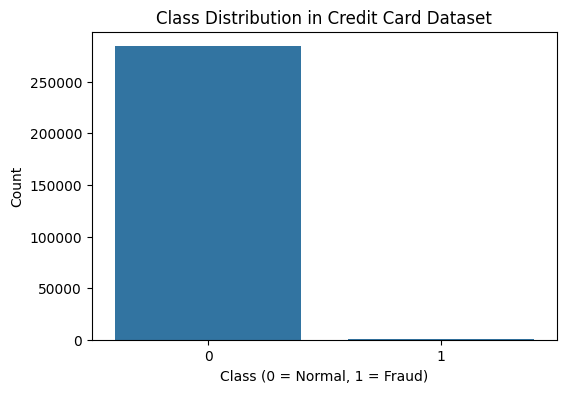

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="Class", data=credit_df)
plt.title("Class Distribution in Credit Card Dataset")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [14]:
X_credit, X_credit_scaled, y_credit = preprocess_data(
    credit_df,
    target_col="Class"
)

In [15]:
credit_results = run_models(
    X_credit_scaled,
    contamination=0.01
)

credit_summary = summarize_results(credit_results)
credit_summary

,Model,Normal Points,Anomalies,Anomaly %,Runtime (s)
0,Isolation Forest,281958,2849,1.0,3.3333
1,Local Outlier Factor,281958,2849,1.0,244.3461


### Credit Card Dataset Discussion

The Credit Card dataset is highly imbalanced because fraudulent transactions represent only a very small portion of the data.

Isolation Forest was able to detect a group of suspicious transactions without using the class labels during training.

Since the dataset contains labels, the results were evaluated using a confusion matrix and classification report. However, the model is unsupervised, so it is not expected to perform like a supervised fraud classification model.

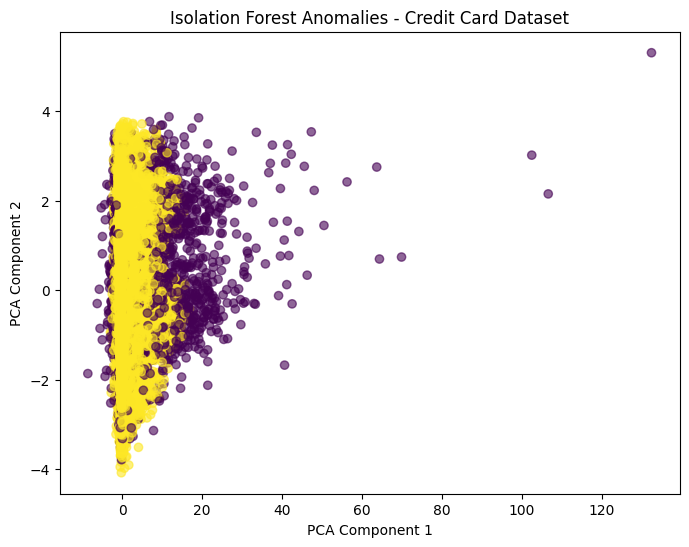

In [16]:
iso_credit_preds = credit_results["Isolation Forest"]["predictions"]

plot_pca_anomalies(
    X_credit_scaled,
    iso_credit_preds,
    "Isolation Forest Anomalies - Credit Card Dataset"
)

### Results Analysis

From the results, both Isolation Forest and Local Outlier Factor detected approximately 1% of the data as anomalies.

This matches the contamination parameter, which was set to 0.01, meaning the model expects around 1% of the data to be anomalous.

It is also noticeable that:
- Isolation Forest performed much faster (~3 seconds)
- Local Outlier Factor took significantly longer (~244 seconds)

This shows that Isolation Forest is more efficient and scalable for large datasets.

From the visualization, most data points are clustered together, representing normal transactions, while a few scattered points are detected as anomalies.

These scattered points may represent potential fraudulent transactions or unusual behavior.

In [22]:
def explain_anomalies_by_feature(X_original, predictions, top_n=10):
    df_explain = X_original.copy()
    df_explain["anomaly"] = predictions
    
    normal_data = df_explain[df_explain["anomaly"] == 1].drop(columns=["anomaly"])
    anomaly_data = df_explain[df_explain["anomaly"] == -1].drop(columns=["anomaly"])
    
    normal_mean = normal_data.mean()
    anomaly_mean = anomaly_data.mean()
    
    difference = abs(anomaly_mean - normal_mean)
    
    explanation = pd.DataFrame({
        "Normal Mean": normal_mean,
        "Anomaly Mean": anomaly_mean,
        "Difference": difference
    }).sort_values(by="Difference", ascending=False)
    
    return explanation.head(top_n)

In [23]:
credit_feature_explanation = explain_anomalies_by_feature(
    X_credit,
    iso_credit_preds,
    top_n=10
)

credit_feature_explanation

,Normal Mean,Anomaly Mean,Difference
Time,94827.251821,93488.464373,1338.787448
Amount,80.298896,885.108378,804.809482
V1,0.085105,-8.422642,8.507747
V3,0.045851,-4.537791,4.583643
V5,0.024479,-2.422615,2.447094
V8,0.019409,-1.920848,1.940257
V2,0.018027,-1.784045,1.802072
V4,-0.014974,1.481938,1.496912
V14,0.011602,-1.148200,1.159802
V9,-0.009615,0.951606,0.961222


### Feature Difference Analysis - Credit Card Dataset

The analysis shows that some features have significantly different average values between normal and anomalous points.

For example:
- "Amount" has a much higher average in anomalies, indicating unusual transaction sizes
- Features like V1, V3, and V5 show large differences, suggesting strong deviation from normal patterns

This indicates that anomalies are not random, but are associated with unusual combinations of feature values.

Although Isolation Forest does not explicitly explain its decisions, this analysis helps identify which features contributed most to detecting anomalies.

________________________________________________________________

## Dataset 2: IoT Sensor Data

The second dataset contains sensor readings from IoT devices.

In this domain, anomaly detection is important because unusual sensor values may indicate:
- Device malfunction
- System failure
- Abnormal environmental conditions

Unlike the previous dataset, this dataset may not contain labels, so the evaluation will be based on model behavior and visualization.

In [17]:
basic_info(iot_df, "IoT Sensor Dataset")

Dataset: IoT Sensor Dataset
Shape: (3000, 5)

First 5 rows:


,Device_ID,Temperature,Humidity,Battery_Level,Anomaly
0,DHT11_B,-0.555734,-0.157264,0.377032,0
1,DHT11_A,-0.266879,-0.086229,-0.217410,0
2,DHT11_B,0.128544,0.041150,0.090479,0
3,DHT11_D,-1.001516,-0.320621,-0.705341,0
4,DHT11_D,0.311015,0.115365,0.807002,0



Missing values:
Device_ID        0
Temperature      0
Humidity         0
Battery_Level    0
Anomaly          0
dtype: int64


In [19]:
X_iot, X_iot_scaled, y_iot = preprocess_data(iot_df)

In [20]:
iot_results = run_models(
    X_iot_scaled,
    contamination=0.05  # أعلى شوي من قبل
)

iot_summary = summarize_results(iot_results)
iot_summary

,Model,Normal Points,Anomalies,Anomaly %,Runtime (s)
0,Isolation Forest,2850,150,5.0,0.2405
1,Local Outlier Factor,2850,150,5.0,0.0326


### IoT Dataset Discussion

In the IoT dataset, there are no labels available, so the evaluation is based on the model's ability to detect unusual patterns.

The model identified a percentage of the data as anomalies based on the contamination parameter.

These anomalies may represent abnormal sensor readings, potential faults, or unexpected environmental changes.

Since anomaly detection is unsupervised, the results are interpreted based on patterns and visualization rather than exact accuracy.

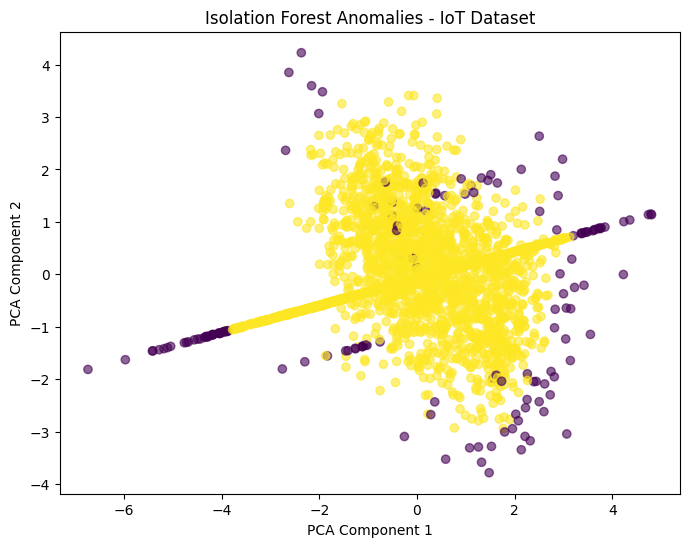

In [21]:
iso_iot_preds = iot_results["Isolation Forest"]["predictions"]

plot_pca_anomalies(
    X_iot_scaled,
    iso_iot_preds,
    "Isolation Forest Anomalies - IoT Dataset"
)

### Results Analysis

In the IoT dataset, both Isolation Forest and Local Outlier Factor detected approximately 5% of the data as anomalies.

This aligns with the contamination parameter set to 0.05, indicating that the model was configured to consider a higher proportion of unusual data points.

From the visualization:
- Most points are clustered together, representing normal sensor behavior
- Some points are scattered away from the main cluster, indicating potential anomalies

These anomalies may represent:
- Sensor malfunction
- Abnormal readings
- Environmental changes

Since the dataset does not contain labels, the evaluation is based on the distribution and visualization rather than classification metrics.

In [24]:
iot_feature_explanation = explain_anomalies_by_feature(
    X_iot,
    iso_iot_preds,
    top_n=10
)

iot_feature_explanation

,Normal Mean,Anomaly Mean,Difference
Anomaly,0.154737,0.540000,0.385263
Battery_Level,0.002012,-0.209674,0.211686
Temperature,-0.232814,-0.360152,0.127338
Humidity,-0.070073,-0.114116,0.044044


### Feature Difference Analysis - IoT Dataset

The analysis highlights that features such as Battery Level and Temperature show noticeable differences between normal and anomalous points.

For instance:
- Battery Level in anomalies is significantly lower
- Temperature values differ from normal behavior

These differences suggest that anomalies may be caused by:
- Sensor malfunction
- Abnormal environmental conditions

This simple comparison provides insight into why certain readings were flagged as anomalies.